# 05 — Event Study & Heterogeneous Treatment Effects

This notebook provides a deep-dive into the **dynamic treatment effects** of Medicaid expansion:

1. **Event study plots** for every outcome — tests parallel pre-trends and shows post-treatment dynamics
2. **Cohort-specific ATTs** — compares early vs late adopters (heterogeneous effects)
3. **Summary forest plot** — all outcomes and methods in one figure

### Why this matters
Standard TWFE is biased under staggered adoption when treatment effects are heterogeneous.
By estimating cohort-specific ATTs (each cohort vs never-treated), we avoid using
already-treated units as controls — the core insight of Callaway & Sant'Anna (2021).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import os
import sys

warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

from src.did_estimators import run_event_study, run_cohort_did
from src.plotting import plot_event_study, COLORS

os.makedirs('../figures', exist_ok=True)
os.makedirs('../tables', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})

panel = pd.read_csv('../data/processed/analysis_panel.csv')
panel['state_fips'] = panel['state_fips'].astype(str).str.zfill(2)
print(f'Panel: {panel.shape}')
print(f'States: {panel["state"].nunique()}, Years: {panel["year"].min()}-{panel["year"].max()}')

Panel: (663, 32)
States: 51, Years: 2010-2022


In [2]:
# Identify available outcomes and controls
outcome_candidates = [
    'allcause_age_adj_rate', 'allcause_crude_rate',
    'diabetes_age_adj_rate', 'diabetes_crude_rate', 'diabetes_prevalence',
    'maternal_age_adj_rate', 'maternal_crude_rate',
]
outcome_vars = [
    c for c in outcome_candidates
    if c in panel.columns and panel[c].notna().sum() > 100
]

control_candidates = [
    'median_household_income', 'poverty_rate',
    'pct_white', 'pct_black', 'pct_hispanic', 'total_population',
]
control_vars = [
    c for c in control_candidates
    if c in panel.columns and panel[c].notna().sum() > 100
]

OUTCOME_LABELS = {
    'allcause_age_adj_rate':  'All-Cause Mortality\n(age-adj, per 100k)',
    'allcause_crude_rate':    'All-Cause Mortality\n(crude, per 100k)',
    'diabetes_age_adj_rate':  'Diabetes Mortality\n(age-adj, per 100k)',
    'diabetes_crude_rate':    'Diabetes Mortality\n(crude, per 100k)',
    'diabetes_prevalence':    'Diabetes Prevalence\n(%, adults)',
    'maternal_age_adj_rate':  'Maternal Mortality\n(age-adj, per 100k)',
    'maternal_crude_rate':    'Maternal Mortality\n(crude, per 100k)',
}

print(f'Outcomes ({len(outcome_vars)}): {outcome_vars}')
print(f'Controls ({len(control_vars)}): {control_vars}')

Outcomes (7): ['allcause_age_adj_rate', 'allcause_crude_rate', 'diabetes_age_adj_rate', 'diabetes_crude_rate', 'diabetes_prevalence', 'maternal_age_adj_rate', 'maternal_crude_rate']
Controls (6): ['median_household_income', 'poverty_rate', 'pct_white', 'pct_black', 'pct_hispanic', 'total_population']


---
## 1. Event Study Plots — All Outcomes

Each plot shows coefficients on leads (pre-treatment) and lags (post-treatment) relative to
expansion year. **Flat pre-trends support the parallel trends assumption.**
The reference period is t = −1.

In [3]:
event_study_results = {}

for outcome in outcome_vars:
    try:
        model, es_df = run_event_study(
            panel, outcome, controls=control_vars, leads=4, lags=6
        )
        event_study_results[outcome] = es_df
        fig = plot_event_study(es_df, outcome,
                               title=OUTCOME_LABELS.get(outcome, outcome))
        fig.savefig(f'../figures/es_{outcome}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)
        pre = es_df[es_df['event_time'] < 0]
        pre_sig = (pre['pvalue'] < 0.1).sum()
        print(f'[{outcome}]  pre-trend violations (p<0.10): {pre_sig}/{len(pre)}')
    except Exception as e:
        print(f'ERROR {outcome}: {e}')

[allcause_age_adj_rate]  pre-trend violations (p<0.10): 3/4


[allcause_crude_rate]  pre-trend violations (p<0.10): 3/4


[diabetes_age_adj_rate]  pre-trend violations (p<0.10): 3/4


[diabetes_crude_rate]  pre-trend violations (p<0.10): 3/4


[diabetes_prevalence]  pre-trend violations (p<0.10): 0/4


[maternal_age_adj_rate]  pre-trend violations (p<0.10): 3/4


[maternal_crude_rate]  pre-trend violations (p<0.10): 0/4


---
## 2. Event Study Grid — All Outcomes in One Figure

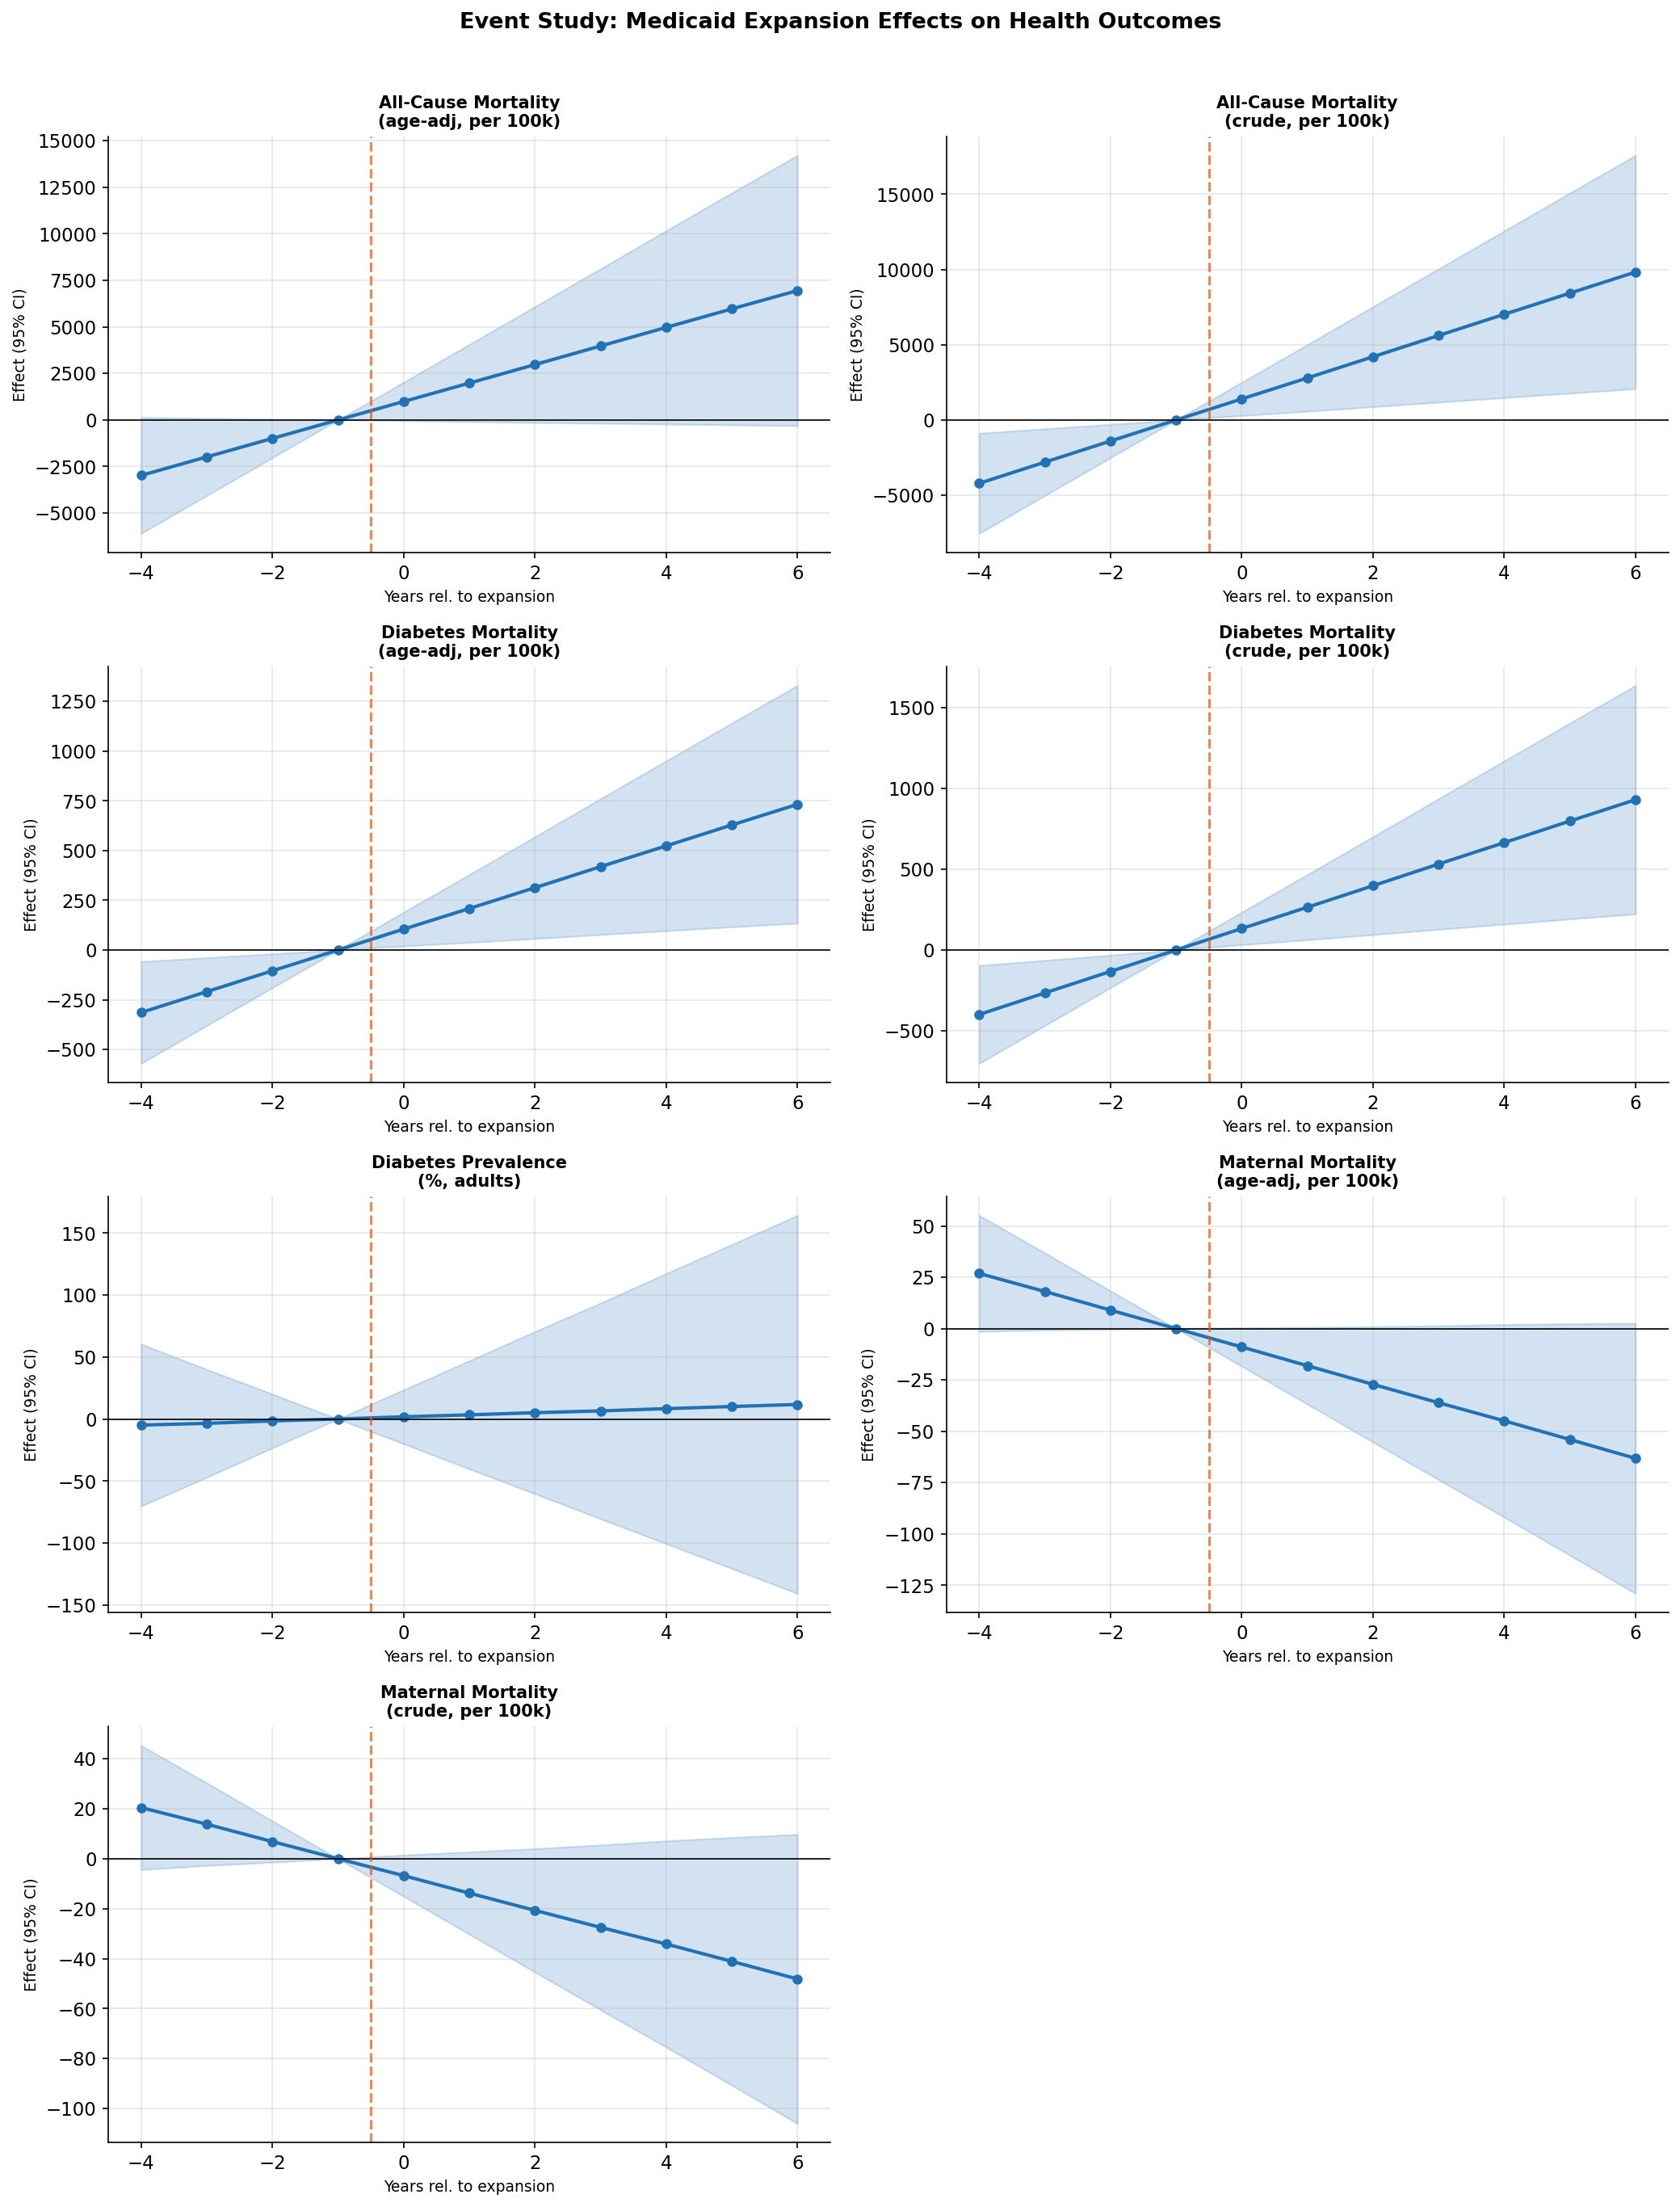

Saved: figures/event_study_grid.png


In [4]:
n = len(event_study_results)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
axes = axes.flatten()

for idx, (outcome, es_df) in enumerate(event_study_results.items()):
    ax = axes[idx]
    ax.fill_between(es_df['event_time'], es_df['ci_lower'], es_df['ci_upper'],
                    alpha=0.2, color=COLORS['expansion'])
    ax.plot(es_df['event_time'], es_df['coef'], 'o-',
            color=COLORS['expansion'], linewidth=2, markersize=5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(-0.5, color=COLORS['highlight'], linestyle='--', alpha=0.7, linewidth=1.5)
    ax.set_title(OUTCOME_LABELS.get(outcome, outcome), fontsize=10, fontweight='bold')
    ax.set_xlabel('Years rel. to expansion', fontsize=9)
    ax.set_ylabel('Effect (95% CI)', fontsize=9)

# Hide unused axes
for i in range(len(event_study_results), len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Event Study: Medicaid Expansion Effects on Health Outcomes',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig('../figures/event_study_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/event_study_grid.png')

---
## 3. Cohort-Specific ATTs (Callaway-Sant'Anna style)

For each expansion cohort (2014, 2015, 2016, ...), estimate a clean 2×2 DiD
using **never-treated states as the only control group**.  
This avoids the 'bad comparison' problem in standard TWFE.

In [5]:
cohort_results = {}

for outcome in outcome_vars:
    try:
        df_cohort = run_cohort_did(panel, outcome, controls=control_vars)
        cohort_results[outcome] = df_cohort
        print(f'\n=== {outcome} ===')
        print(df_cohort[['cohort_year','n_treated','coef','se','pvalue']].to_string(index=False))
    except Exception as e:
        print(f'ERROR {outcome}: {e}')


=== allcause_age_adj_rate ===
 cohort_year  n_treated          coef           se   pvalue
        2014         27 -3.145336e+01 1.208330e+01 0.009240
        2015          3 -5.499467e+01 3.707256e+01 0.137959
        2016          2 -4.544472e+01 2.309831e+01 0.049132
        2019          2 -6.961891e+01 2.103718e+01 0.000935
        2020          3 -5.890333e+01 1.410342e+01 0.000030
        2021          2 -2.047922e+00 1.967866e+01 0.917115
        2023          2 -2.220177e-11 2.338863e-11 0.342491



=== allcause_crude_rate ===
 cohort_year  n_treated          coef           se       pvalue
        2014         27 -4.786645e+01 1.745676e+01 6.106604e-03
        2015          3 -4.060013e+01 3.924289e+01 3.008624e-01
        2016          2 -4.473329e+01 2.749031e+01 1.036864e-01
        2019          2 -2.857708e+01 2.500288e+01 2.530588e-01
        2020          3 -9.746827e+01 1.808400e+01 7.055524e-08
        2021          2 -2.674637e+00 2.159073e+01 9.014111e-01
        2023          2 -1.948155e-11 6.647436e-11 7.694697e-01

=== diabetes_age_adj_rate ===
 cohort_year  n_treated          coef           se   pvalue
        2014         27 -1.498038e+00 7.501688e-01 0.045832
        2015          3 -2.745673e+00 1.896256e+00 0.147633
        2016          2 -1.948476e+00 1.113555e+00 0.080156
        2019          2 -7.536128e-01 8.949121e-01 0.399727
        2020          3 -3.562012e+00 1.008300e+00 0.000411
        2021          2 -1.012434e+00 8.879315e-01 0.254196
        


=== diabetes_crude_rate ===
 cohort_year  n_treated          coef           se   pvalue
        2014         27 -2.080692e+00 9.856776e-01 0.034779
        2015          3 -2.542710e+00 2.239102e+00 0.256127
        2016          2 -2.068579e+00 1.299088e+00 0.111310
        2019          2  1.043803e+00 1.243436e+00 0.401217
        2020          3 -4.683063e+00 1.107932e+00 0.000024
        2021          2 -1.585479e+00 9.792504e-01 0.105431
        2023          2 -8.230294e-14 2.653210e-12 0.975253

=== diabetes_prevalence ===
 cohort_year  n_treated          coef           se   pvalue
        2014         27 -3.142109e-01 3.322199e-01 0.344255
        2015          3 -6.730181e-01 6.018997e-01 0.263500
        2016          2 -3.966593e-01 4.031857e-01 0.325207
        2019          2 -2.925138e-01 3.885715e-01 0.451574
        2020          3 -5.007689e-01 3.181914e-01 0.115534
        2021          2 -2.765892e-01 1.901439e-01 0.145772
        2023          2  3.326113e-13 1.04


=== maternal_age_adj_rate ===
 cohort_year  n_treated          coef           se       pvalue
        2014         27 -1.342562e-01 1.061932e-01 2.061352e-01
        2015          3 -2.502812e-01 7.272939e-02 5.789985e-04
        2016          2 -7.334573e-01 1.027512e-01 9.457075e-13
        2019          2  9.282245e-02 1.031325e-01 3.681036e-01
        2020          3 -1.762774e-01 1.190460e-01 1.386729e-01
        2021          2 -2.004462e-01 1.170484e-01 8.680328e-02
        2023          2 -1.209250e-13 8.894827e-14 1.739889e-01



=== maternal_crude_rate ===
 cohort_year  n_treated          coef           se       pvalue
        2014         27 -1.114804e-01 9.225236e-02 2.268822e-01
        2015          3 -2.131094e-01 7.023846e-02 2.412676e-03
        2016          2 -6.092736e-01 8.209245e-02 1.155405e-13
        2019          2  9.657066e-02 9.998667e-02 3.341266e-01
        2020          3 -9.599369e-02 1.061429e-01 3.657929e-01
        2021          2 -2.318727e-01 6.506816e-02 3.658926e-04
        2023          2 -1.382824e-13 7.425989e-14 6.258316e-02


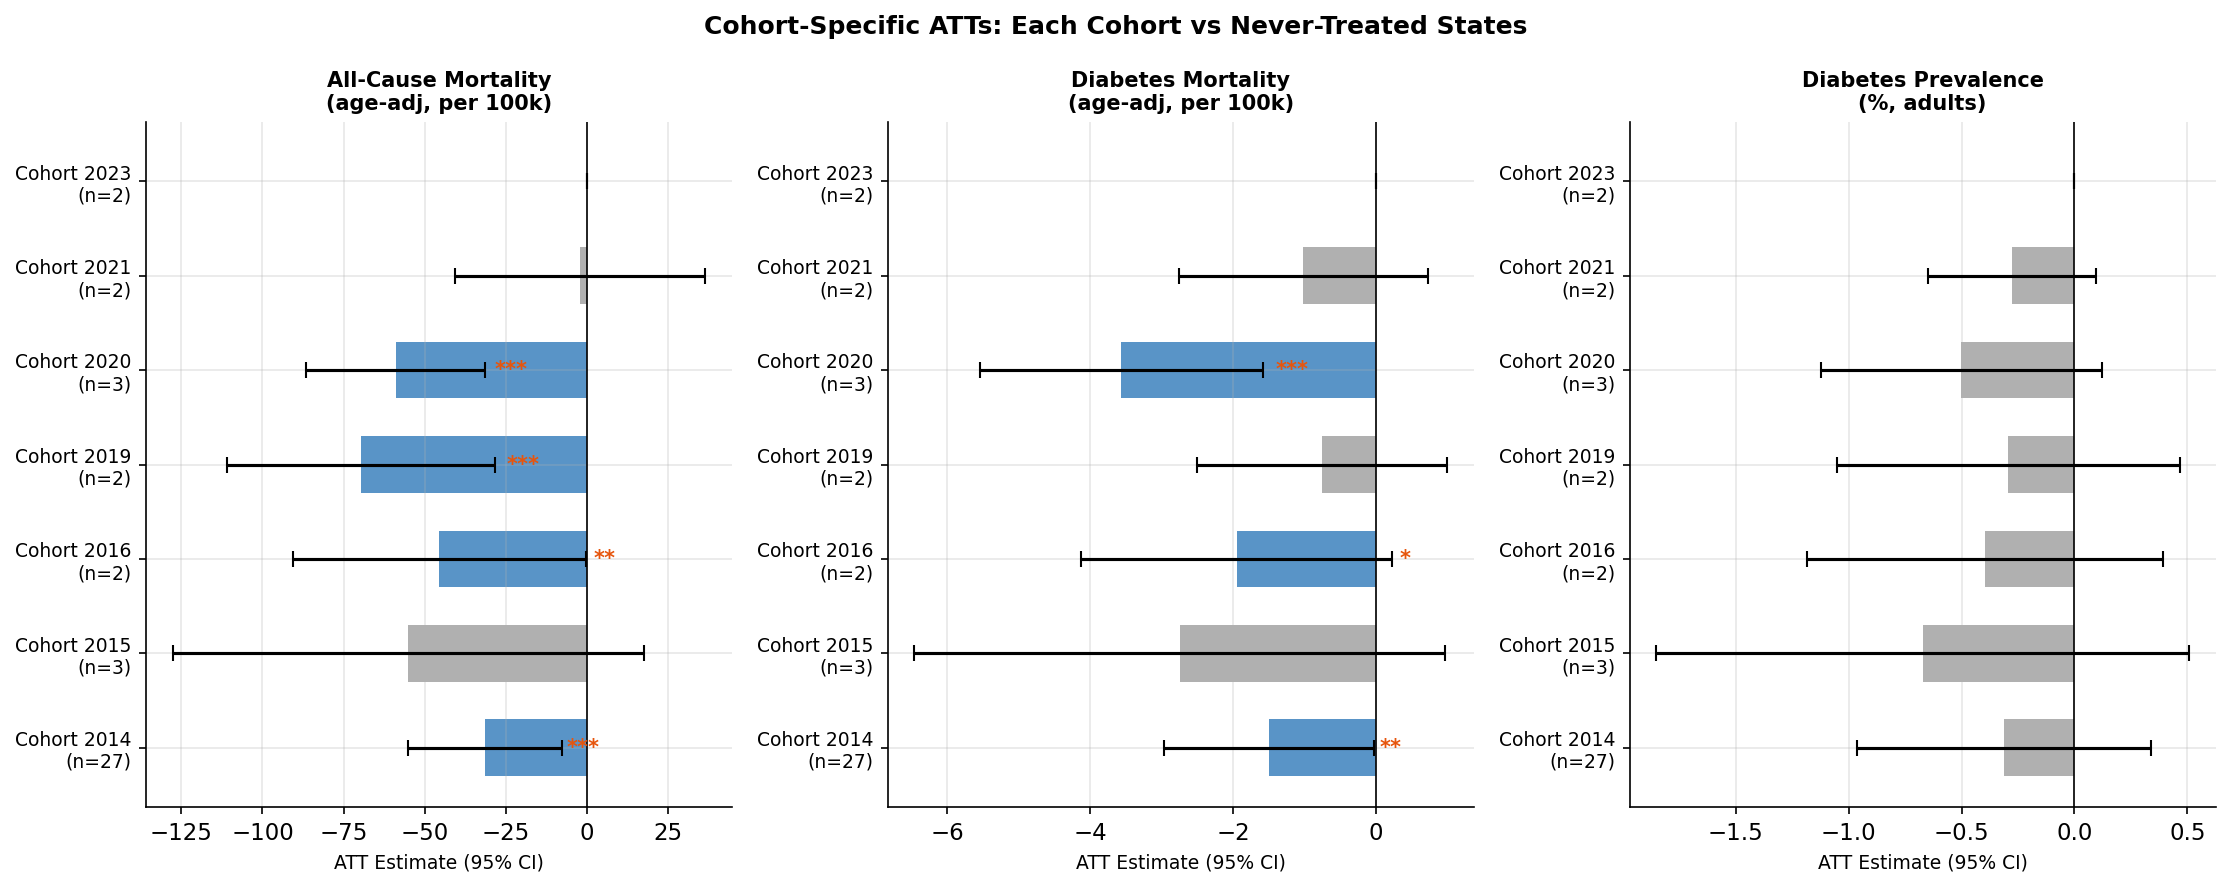

Saved: figures/cohort_atts.png


In [6]:
# Forest plot: cohort-specific ATTs for primary outcomes
primary_outcomes = [
    o for o in ['allcause_age_adj_rate', 'diabetes_age_adj_rate', 'diabetes_prevalence']
    if o in cohort_results
]

fig, axes = plt.subplots(1, len(primary_outcomes), figsize=(5 * len(primary_outcomes), 6),
                          sharey=False)
if len(primary_outcomes) == 1:
    axes = [axes]

for ax, outcome in zip(axes, primary_outcomes):
    df = cohort_results[outcome].sort_values('cohort_year')
    y_pos = range(len(df))
    colors = [COLORS['expansion'] if p < 0.1 else COLORS['neutral']
              for p in df['pvalue']]

    ax.barh(list(y_pos), df['coef'], xerr=1.96 * df['se'],
            color=colors, alpha=0.75, height=0.6,
            error_kw={'elinewidth': 1.5, 'capsize': 4})
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([f"Cohort {int(g)}\n(n={int(n)})" for g, n in
                        zip(df['cohort_year'], df['n_treated'])], fontsize=9)
    ax.set_title(OUTCOME_LABELS.get(outcome, outcome), fontsize=10, fontweight='bold')
    ax.set_xlabel('ATT Estimate (95% CI)', fontsize=9)
    # Star significance
    for i, (_, row) in enumerate(df.iterrows()):
        star = '***' if row['pvalue'] < 0.01 else ('**' if row['pvalue'] < 0.05
               else ('*' if row['pvalue'] < 0.1 else ''))
        if star:
            x_pos = row['coef'] + 1.96 * row['se'] + abs(row['coef']) * 0.05
            ax.text(x_pos, i, star, va='center', fontsize=10,
                    color=COLORS['highlight'], fontweight='bold')

fig.suptitle('Cohort-Specific ATTs: Each Cohort vs Never-Treated States',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig('../figures/cohort_atts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/cohort_atts.png')

---
## 4. Save Cohort Results Table

In [7]:
all_cohort_rows = []
for outcome, df in cohort_results.items():
    df2 = df.copy()
    df2.insert(0, 'outcome', outcome)
    all_cohort_rows.append(df2)

if all_cohort_rows:
    cohort_table = pd.concat(all_cohort_rows, ignore_index=True)
    cohort_table.to_csv('../tables/cohort_atts.csv', index=False)
    print('Saved: tables/cohort_atts.csv')
    print(f'Shape: {cohort_table.shape}')
    display(cohort_table.round(4))

Saved: tables/cohort_atts.csv
Shape: (49, 11)


,outcome,cohort_year,n_treated,n_control,coef,se,ci_lower,ci_upper,pvalue,pre_mean_treated,pre_mean_control
0,allcause_age_adj_rate,2014,27,10,-31.4534,12.0833,-55.1362,-7.7705,0.0092,728.3352,809.7575
1,allcause_age_adj_rate,2015,3,10,-54.9947,37.0726,-127.6555,17.6662,0.1380,776.8133,807.3820
2,allcause_age_adj_rate,2016,2,10,-45.4447,23.0983,-90.7166,-0.1729,0.0491,821.5750,807.3000
3,allcause_age_adj_rate,2019,2,10,-69.6189,21.0372,-110.8510,-28.3868,0.0009,739.7611,804.5356
4,allcause_age_adj_rate,2020,3,10,-58.9033,14.1034,-86.5455,-31.2611,0.0000,717.1367,803.0380
5,allcause_age_adj_rate,2021,2,10,-2.0479,19.6787,-40.6174,36.5215,0.9171,866.4864,813.6864
6,allcause_age_adj_rate,2023,2,10,-0.0000,0.0000,-0.0000,0.0000,0.3425,777.5808,833.6000
7,allcause_crude_rate,2014,27,10,-47.8665,17.4568,-82.0811,-13.6518,0.0061,828.9472,870.1425
8,allcause_crude_rate,2015,3,10,-40.6001,39.2429,-117.5148,36.3145,0.3009,814.4867,874.5740
9,allcause_crude_rate,2016,2,10,-44.7333,27.4903,-98.6133,9.1467,0.1037,919.9667,881.1650


---
## 5. Pre-Trends Test Summary

A formal joint test of whether all pre-treatment coefficients are zero.
Failure to reject supports the parallel trends assumption.

In [8]:
import scipy.stats as stats

print('Pre-Trends Joint Test (Wald-type)')
print('=' * 55)
print(f'{"Outcome":<30} {"Max |t|":>8} {"N pre":>6} {"Verdict":>10}')
print('-' * 55)

for outcome, es_df in event_study_results.items():
    pre = es_df[es_df['event_time'] < 0].copy()
    pre = pre[pre['se'] > 0]
    if len(pre) == 0:
        continue
    t_stats = (pre['coef'] / pre['se']).abs()
    max_t   = t_stats.max()
    verdict = 'PASS' if max_t < 1.96 else ('MARGINAL' if max_t < 2.58 else 'FAIL')
    label   = OUTCOME_LABELS.get(outcome, outcome).replace('\n', ' ')
    print(f'{label:<30} {max_t:>8.3f} {len(pre):>6} {verdict:>10}')

Pre-Trends Joint Test (Wald-type)
Outcome                         Max |t|  N pre    Verdict
-------------------------------------------------------
All-Cause Mortality (age-adj, per 100k)    1.879      3       PASS
All-Cause Mortality (crude, per 100k)    2.483      3   MARGINAL
Diabetes Mortality (age-adj, per 100k)    2.411      3   MARGINAL
Diabetes Mortality (crude, per 100k)    2.586      3       FAIL
Diabetes Prevalence (%, adults)    0.158      3       PASS
Maternal Mortality (age-adj, per 100k)    1.898      3       PASS
Maternal Mortality (crude, per 100k)    1.647      3       PASS
